# S6 — Secondary models

Secondary endpoints:
1) ep_non_hdl   : non-HDL >= 130 mg/dL
2) ep_ogtt120   : OGTT 120' glucose >= 140 mg/dL

Exposure: tai_A
Minimal adjustment set: age (centered, consistent with S5)

Binary models:
- Firth logistic regression + bootstrap 95% CI for OR
- Calibration curve (descriptive only)

 Continuous companion models:
- non_hdl ~ TAI_A + age_c
- glu120  ~ TAI_A + age_c

## Imports

In [ ]:
import json
import logging
from pathlib import Path
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LinearRegression

## Config

In [ ]:
def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def resolve_config_path() -> Path:
    candidates = [
        Path("/content/reports/config_snapshot.json"),
        Path("/mnt/data/config_snapshot.json"),
        Path("/content/config.json"),
        Path("/mnt/data/config.json"),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "No config found. Expected config_snapshot.json or config.json in /content or /mnt/data."
    )

CONFIG_PATH = resolve_config_path()
CFG = load_json(CONFIG_PATH)

print("Loaded config:", str(CONFIG_PATH))

Loaded config: /content/config.json


## Directories and logging

In [ ]:
def ensure_dirs(cfg: dict) -> None:
    path_keys = [
        "output_dir",
        "intermediate_dir",
        "figures_dir",
        "tables_dir",
        "models_dir",
        "reports_dir",
        "qc_dir",
        "supplementary_dir",
    ]
    for key in path_keys:
        if key in cfg.get("paths", {}):
            Path(cfg["paths"][key]).mkdir(parents=True, exist_ok=True)

def setup_logging(cfg: dict) -> None:
    if not cfg.get("logging", {}).get("enabled", False):
        return

    root_logger = logging.getLogger()
    if root_logger.handlers:
        root_logger.setLevel(logging.INFO)
        return

    log_file = Path(cfg["logging"]["log_file"])
    log_file.parent.mkdir(parents=True, exist_ok=True)

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(message)s",
        handlers=[
            logging.FileHandler(log_file, encoding="utf-8"),
            logging.StreamHandler(),
        ],
    )
    logging.info("Logging initialized in S6.")
    logging.info("Config loaded from: %s", str(CONFIG_PATH))

ensure_dirs(CFG)
setup_logging(CFG)

tables_dir = Path(CFG["paths"]["tables_dir"])
figures_dir = Path(CFG["paths"]["figures_dir"])
models_dir = Path(CFG["paths"]["models_dir"])
reports_dir = Path(CFG["paths"]["reports_dir"])
intermediate_dir = Path(CFG["paths"]["intermediate_dir"])

## Load pcos_analysis

In [ ]:
def resolve_analysis_data_paths(cfg: dict) -> List[Path]:
    return [
        Path(cfg["paths"]["intermediate_dir"]) / "pcos_analysis.parquet",
        Path(cfg["paths"]["intermediate_dir"]) / "pcos_analysis.csv",
        Path("/content/pcos_analysis.parquet"),
        Path("/content/pcos_analysis.csv"),
        Path("/mnt/data/pcos_analysis.parquet"),
        Path("/mnt/data/pcos_analysis.csv"),
    ]

def load_analysis_dataset(cfg: dict) -> Tuple[pd.DataFrame, str]:
    candidates = resolve_analysis_data_paths(cfg)

    parquet_candidates = [p for p in candidates if p.suffix == ".parquet" and p.exists()]
    csv_candidates = [p for p in candidates if p.suffix == ".csv" and p.exists()]

    for p in parquet_candidates:
        try:
            df = pd.read_parquet(p)
            return df, str(p)
        except Exception as e:
            logging.warning("Failed to read parquet %s: %r", str(p), e)

    for p in csv_candidates:
        try:
            df = pd.read_csv(p)
            return df, str(p)
        except Exception as e:
            logging.warning("Failed to read csv %s: %r", str(p), e)

    raise FileNotFoundError(
        "Could not locate pcos_analysis.parquet or pcos_analysis.csv in configured/intermediate locations."
    )

df, source_used = load_analysis_dataset(CFG)

print("Loaded:", source_used)
print("Shape:", df.shape)
df.head(3)

Loaded: /content/pcos_analysis.parquet
Shape: (1300, 77)


,id,age,anti_tpo,anti_tg,tsh,ft4,ft3,tg,hdl,tc,...,analysis_primary_minimal,analysis_non_hdl_minimal,analysis_ogtt120_minimal,exposure_tai_A_defined,endpoint_primary_defined,endpoint_non_hdl_defined,endpoint_ogtt120_defined,analysis_primary_eligible,analysis_non_hdl_eligible,analysis_ogtt120_eligible
0,7611,25.0,13.8,NaN,0.969,1.20,NaN,116.0,56.6,188.0,...,True,True,True,True,True,True,True,True,True,True
1,8133,25.0,12.6,NaN,2.050,1.18,NaN,144.0,41.9,196.0,...,True,True,True,True,True,True,True,True,True,True
2,11028,25.0,150.0,NaN,2.500,1.29,NaN,35.8,62.7,133.0,...,True,True,True,True,True,True,True,True,True,True


## Helpers

In [ ]:
def add_intercept(X: np.ndarray) -> np.ndarray:
    return np.column_stack([np.ones(X.shape[0]), X])

def _safe_expit(z: np.ndarray) -> np.ndarray:
    return np.clip(expit(z), 1e-10, 1 - 1e-10)

def _firth_step_components(X: np.ndarray, y: np.ndarray, beta: np.ndarray):
    eta = X @ beta
    p = _safe_expit(eta)
    W = np.clip(p * (1 - p), 1e-10, None)

    XtWX = X.T @ (W[:, None] * X)
    XtWX_inv = np.linalg.pinv(XtWX)

    quad = np.einsum("ij,jk,ik->i", X, XtWX_inv, X)
    h = np.clip(W * quad, 0.0, 1.0)

    a = h * (0.5 - p)
    U_star = X.T @ (y - p + a)

    return p, W, XtWX, XtWX_inv, h, a, U_star

def fit_firth_logistic(
    X: np.ndarray,
    y: np.ndarray,
    maxiter: int = 200,
    tol: float = 1e-8,
    max_halving: int = 25
) -> Dict[str, Any]:

    beta = np.zeros(X.shape[1], dtype=float)

    def penalized_objective(b: np.ndarray) -> float:
        eta = X @ b
        p = _safe_expit(eta)
        W = np.clip(p * (1 - p), 1e-10, None)
        XtWX = X.T @ (W[:, None] * X)
        sign, logdet = np.linalg.slogdet(XtWX)
        if sign <= 0:
            return np.inf
        loglik = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
        return -(loglik + 0.5 * logdet)

    obj = penalized_objective(beta)
    converged = False
    message = "Maximum iterations reached"

    for it in range(1, maxiter + 1):
        p, W, XtWX, XtWX_inv, h, a, U_star = _firth_step_components(X, y, beta)

        step = XtWX_inv @ U_star

        if np.max(np.abs(U_star)) < tol and np.max(np.abs(step)) < tol:
            converged = True
            message = "Converged"
            break

        beta_candidate = beta + step
        obj_candidate = penalized_objective(beta_candidate)

        halving = 0
        while (not np.isfinite(obj_candidate) or obj_candidate > obj) and halving < max_halving:
            step = step / 2.0
            beta_candidate = beta + step
            obj_candidate = penalized_objective(beta_candidate)
            halving += 1

        if np.isfinite(obj_candidate) and obj_candidate <= obj:
            beta = beta_candidate
            obj = obj_candidate
        else:
            message = "Step-halving failed to improve objective"
            break

        if np.max(np.abs(step)) < tol:
            converged = True
            message = "Converged"
            break

    eta = X @ beta
    p = _safe_expit(eta)
    W = np.clip(p * (1 - p), 1e-10, None)
    XtWX = X.T @ (W[:, None] * X)
    cov = np.linalg.pinv(XtWX)

    return {
        "beta": beta,
        "p": p,
        "cov": cov,
        "converged": bool(converged),
        "message": str(message),
        "n_iter": int(it),
        "objective": float(obj),
        "optimizer": "firth_adjusted_score",
    }

def bootstrap_firth_or_ci(
    X: np.ndarray,
    y: np.ndarray,
    term_names: List[str],
    n_boot: int,
    seed: int
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = len(y)
    boot_betas = []
    n_nonconverged = 0
    n_failed = 0

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        Xb = X[idx]
        yb = y[idx]

        if len(np.unique(yb)) < 2:
            n_failed += 1
            continue

        try:
            fit_b = fit_firth_logistic(Xb, yb)
            if not fit_b["converged"]:
                n_nonconverged += 1
            boot_betas.append(fit_b["beta"])
        except Exception:
            n_failed += 1
            continue

    if len(boot_betas) == 0:
        raise RuntimeError("No successful bootstrap fits for Firth model.")

    boot_betas = np.asarray(boot_betas)

    print(
        f"Bootstrap summary: {len(boot_betas)} successful fits, "
        f"{n_nonconverged} not fully converged, {n_failed} failed/skipped."
    )

    rows = []
    for j, term in enumerate(term_names):
        vals = boot_betas[:, j]
        rows.append({
            "term": term,
            "beta_boot_median": float(np.median(vals)),
            "OR_boot_median": float(np.exp(np.median(vals))),
            "CI_low": float(np.exp(np.quantile(vals, 0.025))),
            "CI_high": float(np.exp(np.quantile(vals, 0.975))),
            "n_boot_success": int(len(boot_betas)),
            "n_boot_nonconverged": int(n_nonconverged),
            "n_boot_failed_or_skipped": int(n_failed),
        })
    return pd.DataFrame(rows)

def bootstrap_linear_ci(
    X: np.ndarray,
    y: np.ndarray,
    feature_names: List[str],
    n_boot: int,
    seed: int
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = len(y)
    betas = []

    m0 = LinearRegression()
    m0.fit(X, y)
    beta_hat = m0.coef_.ravel()

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        Xb = X[idx]
        yb = y[idx]
        m = LinearRegression()
        try:
            m.fit(Xb, yb)
            betas.append(m.coef_.ravel())
        except Exception:
            continue

    if len(betas) == 0:
        raise RuntimeError("Bootstrap failed for linear regression.")

    betas = np.vstack(betas)

    rows = []
    for j, fn in enumerate(feature_names):
        rows.append({
            "term": fn,
            "beta_hat": float(beta_hat[j]),
            "CI_low": float(np.quantile(betas[:, j], 0.025)),
            "CI_high": float(np.quantile(betas[:, j], 0.975)),
            "n_boot_success": int(len(betas)),
        })
    return pd.DataFrame(rows)

## Definition of the model cohort

In [ ]:
def to_bool01(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce").astype("Int64")

def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")

def summarize_events(dfm: pd.DataFrame, exposure_col: str, endpoint_col: str) -> Dict[str, int]:
    x = to_bool01(dfm[exposure_col]).astype(int)
    y = to_bool01(dfm[endpoint_col]).astype(int)

    return {
        "n": int(len(dfm)),
        "events": int(y.sum()),
        "n_tai_pos": int((x == 1).sum()),
        "n_tai_neg": int((x == 0).sum()),
        "events_tai_pos": int(((x == 1) & (y == 1)).sum()),
        "events_tai_neg": int(((x == 0) & (y == 1)).sum()),
    }

def build_secondary_binary_cohort(
    df: pd.DataFrame,
    endpoint: str,
    eligibility_flag: str,
    exposure: str = "tai_A",
    age_col: str = "age",
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, float]:
    required = [eligibility_flag, exposure, endpoint, age_col]
    missing_required = [c for c in required if c not in df.columns]
    if missing_required:
        raise KeyError(f"Missing required columns: {missing_required}")

    dfm = df.loc[df[eligibility_flag] == True].copy()
    dfm = dfm[dfm[exposure].notna() & dfm[endpoint].notna() & dfm[age_col].notna()].copy()
    dfm = dfm.reset_index(drop=True)

    X = pd.DataFrame({
        "TAI_A": to_bool01(dfm[exposure]).astype(int),
        "age_num": to_num(dfm[age_col]),
    })

    age_mean = float(X["age_num"].mean())
    X["age_c"] = X["age_num"] - age_mean
    X = X[["TAI_A", "age_c"]]

    y = to_bool01(dfm[endpoint]).astype(int)

    mask = X.notna().all(axis=1) & y.notna()
    X = X.loc[mask].reset_index(drop=True)
    y = y.loc[mask].reset_index(drop=True)
    dfm = dfm.loc[mask.to_numpy()].reset_index(drop=True)

    return dfm, X, y, age_mean

In [ ]:
RANDOM_SEED = int(CFG["project"]["random_seed"])
N_BOOT = 2000
RARE_EVENT_THRESHOLD = int(CFG.get("analysis", {}).get("rare_event_warning_threshold", 10))

EXPOSURE = "tai_A"

SECONDARY_SPECS = [
    {
        "endpoint": "ep_non_hdl",
        "endpoint_label": "non-HDL ≥ 130 mg/dL",
        "eligibility_flag": "analysis_non_hdl_eligible",
        "figure_stub": "non_hdl",
    },
    {
        "endpoint": "ep_ogtt120",
        "endpoint_label": "OGTT 120' glucose ≥ 140 mg/dL",
        "eligibility_flag": "analysis_ogtt120_eligible",
        "figure_stub": "ogtt120",
    },
]

## Define Secondary Endpoints, Exposure, and Analysis Settings


--- ep_non_hdl | non-HDL ≥ 130 mg/dL ---
Cohort n: 1053 | events: 224
Events in TAI+: 19/84
Events in TAI−: 205/969
Mean age used for centering: 21.441595441595442
Bootstrap summary: 2000 successful fits, 1 not fully converged, 0 failed/skipped.


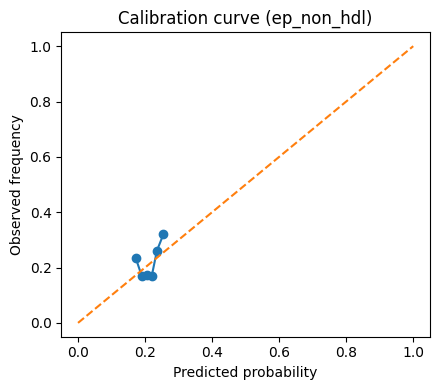

Saved: /content/outputs/figures/F6_calibration_non_hdl.png

--- ep_ogtt120 | OGTT 120' glucose ≥ 140 mg/dL ---
Cohort n: 1035 | events: 156
Events in TAI+: 14/79
Events in TAI−: 142/956
Mean age used for centering: 21.442512077294687
Bootstrap summary: 2000 successful fits, 1 not fully converged, 0 failed/skipped.


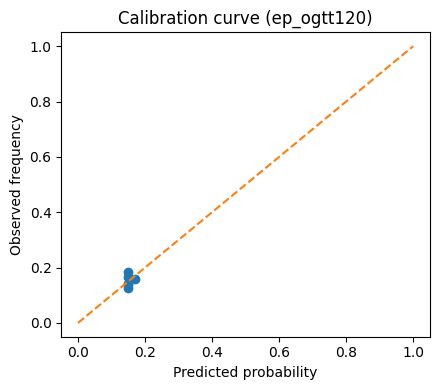

Saved: /content/outputs/figures/F6_calibration_ogtt120.png


In [ ]:
secondary_results = []
secondary_event_counts = []
secondary_summaries = []

for spec in SECONDARY_SPECS:
    endpoint = spec["endpoint"]
    endpoint_label = spec["endpoint_label"]
    eligibility_flag = spec["eligibility_flag"]
    figure_stub = spec["figure_stub"]

    if endpoint not in df.columns:
        logging.warning("Skipping %s: endpoint not present.", endpoint)
        continue
    if eligibility_flag not in df.columns:
        logging.warning("Skipping %s: eligibility flag %s not present.", endpoint, eligibility_flag)
        continue

    dfm, X, y, age_mean = build_secondary_binary_cohort(
        df=df,
        endpoint=endpoint,
        eligibility_flag=eligibility_flag,
        exposure=EXPOSURE,
        age_col="age",
    )

    evt = summarize_events(dfm, EXPOSURE, endpoint)

    warning_parts = []
    if evt["events_tai_pos"] < RARE_EVENT_THRESHOLD:
        warning_parts.append("Sparse events in TAI+")
    if evt["events_tai_neg"] < RARE_EVENT_THRESHOLD:
        warning_parts.append("Sparse events in TAI−")
    if evt["events"] < 30:
        warning_parts.append("Low total event count")

    warning = "; ".join(warning_parts)

    print("\n---", endpoint, "|", endpoint_label, "---")
    print("Cohort n:", evt["n"], "| events:", evt["events"])
    print(f"Events in TAI+: {evt['events_tai_pos']}/{evt['n_tai_pos']}")
    print(f"Events in TAI−: {evt['events_tai_neg']}/{evt['n_tai_neg']}")
    print("Mean age used for centering:", age_mean)
    if warning:
        print("Warning:", warning)

    X_np = X.to_numpy(dtype=float)
    y_np = y.to_numpy(dtype=int)
    X_design = add_intercept(X_np)
    term_names = ["Intercept"] + list(X.columns)

    fit = fit_firth_logistic(X_design, y_np)
    p = fit["p"]

    brier = brier_score_loss(y_np, p)
    try:
        auc = roc_auc_score(y_np, p)
    except Exception:
        auc = np.nan

    boot = bootstrap_firth_or_ci(
        X=X_design,
        y=y_np,
        term_names=term_names,
        n_boot=N_BOOT,
        seed=RANDOM_SEED,
    )

    rows = []
    for j, term in enumerate(term_names):
        beta_hat = float(fit["beta"][j])
        or_hat = float(np.exp(beta_hat))

        row = boot.loc[boot["term"] == term].iloc[0].to_dict()
        row.update({
            "endpoint": endpoint,
            "endpoint_label": endpoint_label,
            "term": term,
            "beta_hat": beta_hat,
            "OR": or_hat,
            "model": f"Secondary: Firth logistic ({endpoint} ~ TAI_A + age_c)",
            "n": evt["n"],
            "events": evt["events"],
            "events_tai_pos": evt["events_tai_pos"],
            "n_tai_pos": evt["n_tai_pos"],
            "events_tai_neg": evt["events_tai_neg"],
            "n_tai_neg": evt["n_tai_neg"],
            "brier_score": brier,
            "auc": auc,
            "converged": fit["converged"],
            "optimizer_message": fit["message"],
            "n_iter": fit["n_iter"],
            "optimizer": fit["optimizer"],
            "age_centering_mean": age_mean,
            "warning": warning,
        })
        rows.append(row)

    secondary_results.append(pd.DataFrame(rows))

    secondary_event_counts.append(pd.DataFrame([{
        "endpoint": endpoint,
        "endpoint_label": endpoint_label,
        "n_total": evt["n"],
        "n_events_total": evt["events"],
        "n_tai_pos": evt["n_tai_pos"],
        "n_events_tai_pos": evt["events_tai_pos"],
        "pct_events_tai_pos": round(evt["events_tai_pos"] / evt["n_tai_pos"] * 100, 2) if evt["n_tai_pos"] > 0 else np.nan,
        "n_tai_neg": evt["n_tai_neg"],
        "n_events_tai_neg": evt["events_tai_neg"],
        "pct_events_tai_neg": round(evt["events_tai_neg"] / evt["n_tai_neg"] * 100, 2) if evt["n_tai_neg"] > 0 else np.nan,
        "warning": warning,
    }]))


    prob_true, prob_pred = calibration_curve(y_np, p, n_bins=8, strategy="quantile")

    plt.figure(figsize=(4.5, 4))
    plt.plot(prob_pred, prob_true, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(f"Calibration curve ({endpoint})")
    plt.tight_layout()

    out_cal = figures_dir / f"F6_calibration_{figure_stub}.png"
    plt.savefig(out_cal, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", out_cal)

    secondary_summaries.append({
        "endpoint": endpoint,
        "endpoint_label": endpoint_label,
        "source_used": source_used,
        "secondary_model_type": "firth_logistic",
        "exposure": EXPOSURE,
        "covariates": ["TAI_A", "age_c"],
        "eligibility_flag": eligibility_flag,
        "n": evt["n"],
        "events": evt["events"],
        "events_tai_pos": evt["events_tai_pos"],
        "n_tai_pos": evt["n_tai_pos"],
        "events_tai_neg": evt["events_tai_neg"],
        "n_tai_neg": evt["n_tai_neg"],
        "brier_score": float(brier),
        "auc": float(auc) if pd.notna(auc) else None,
        "converged": bool(fit["converged"]),
        "optimizer_message": fit["message"],
        "n_iter": int(fit["n_iter"]),
        "optimizer": fit["optimizer"],
        "bootstrap_success": int(boot["n_boot_success"].iloc[0]) if len(boot) else 0,
        "bootstrap_nonconverged": int(boot["n_boot_nonconverged"].iloc[0]) if len(boot) else 0,
        "bootstrap_failed_or_skipped": int(boot["n_boot_failed_or_skipped"].iloc[0]) if len(boot) else 0,
        "age_centering_mean": age_mean,
        "warning": warning,
    })

## Export Secondary Binary Model Results

In [ ]:
table3 = pd.concat(secondary_results, ignore_index=True) if secondary_results else pd.DataFrame()
out_table3 = tables_dir / "Table3_secondary_models.csv"
table3.to_csv(out_table3, index=False)

print("Saved:", out_table3)
table3

Saved: /content/outputs/tables/Table3_secondary_models.csv


,term,beta_boot_median,OR_boot_median,CI_low,CI_high,n_boot_success,n_boot_nonconverged,n_boot_failed_or_skipped,endpoint,endpoint_label,...,events_tai_neg,n_tai_neg,brier_score,auc,converged,optimizer_message,n_iter,optimizer,age_centering_mean,warning
0,Intercept,-1.317693,0.267752,0.227871,0.310083,2000,1,0,ep_non_hdl,non-HDL ≥ 130 mg/dL,...,205,969,0.166722,0.552107,True,Converged,6,firth_adjusted_score,21.441595,
1,TAI_A,0.086289,1.090121,0.611688,1.763087,2000,1,0,ep_non_hdl,non-HDL ≥ 130 mg/dL,...,205,969,0.166722,0.552107,True,Converged,6,firth_adjusted_score,21.441595,
2,age_c,0.088579,1.092621,0.986589,1.213266,2000,1,0,ep_non_hdl,non-HDL ≥ 130 mg/dL,...,205,969,0.166722,0.552107,True,Converged,6,firth_adjusted_score,21.441595,
3,Intercept,-1.746599,0.174366,0.144735,0.207860,2000,1,0,ep_ogtt120,OGTT 120' glucose ≥ 140 mg/dL,...,142,956,0.127951,0.507023,True,Converged,7,firth_adjusted_score,21.442512,
4,TAI_A,0.226890,1.254692,0.625181,2.180289,2000,1,0,ep_ogtt120,OGTT 120' glucose ≥ 140 mg/dL,...,142,956,0.127951,0.507023,True,Converged,7,firth_adjusted_score,21.442512,
5,age_c,-0.002350,0.997653,0.901514,1.108962,2000,1,0,ep_ogtt120,OGTT 120' glucose ≥ 140 mg/dL,...,142,956,0.127951,0.507023,True,Converged,7,firth_adjusted_score,21.442512,


## Export Event Counts for Secondary Endpoints

In [ ]:
secondary_event_counts_df = (
    pd.concat(secondary_event_counts, ignore_index=True)
    if secondary_event_counts else pd.DataFrame()
)

out_evt = tables_dir / "secondary_model_event_counts.csv"
secondary_event_counts_df.to_csv(out_evt, index=False)

print("Saved:", out_evt)
secondary_event_counts_df

Saved: /content/outputs/tables/secondary_model_event_counts.csv


,endpoint,endpoint_label,n_total,n_events_total,n_tai_pos,n_events_tai_pos,pct_events_tai_pos,n_tai_neg,n_events_tai_neg,pct_events_tai_neg,warning
0,ep_non_hdl,non-HDL ≥ 130 mg/dL,1053,224,84,19,22.62,969,205,21.16,
1,ep_ogtt120,OGTT 120' glucose ≥ 140 mg/dL,1035,156,79,14,17.72,956,142,14.85,


## Create Forest Plot for Secondary Endpoint Associations

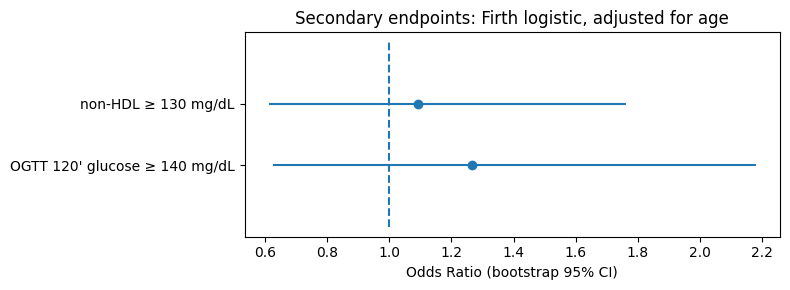

Saved: /content/outputs/figures/F7_forest_secondary_OR.png


In [ ]:
if len(table3) == 0:
    raise RuntimeError("No secondary model results to plot.")

plot_df = (
    table3[table3["term"] == "TAI_A"]
    .copy()
    .sort_values("endpoint_label")
    .reset_index(drop=True)
)

ypos = np.arange(len(plot_df))
or_vals = plot_df["OR"].to_numpy()
lo = plot_df["CI_low"].to_numpy()
hi = plot_df["CI_high"].to_numpy()

plt.figure(figsize=(8, 3))
plt.hlines(ypos, lo, hi)
plt.plot(or_vals, ypos, "o")
plt.vlines(1.0, -1, len(ypos), linestyles="dashed")
plt.yticks(ypos, plot_df["endpoint_label"])
plt.xlabel("Odds Ratio (bootstrap 95% CI)")
plt.title("Secondary endpoints: Firth logistic, adjusted for age")
plt.tight_layout()

out_forest = figures_dir / "F7_forest_secondary_OR.png"
plt.savefig(out_forest, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_forest)

## Fit Continuous Companion Models

In [ ]:
companions = []

# Continuous companion: non-HDL
if {"non_hdl", "age", EXPOSURE}.issubset(df.columns):
    dfc = df[df[EXPOSURE].notna()].copy()

    dfc["non_hdl_num"] = to_num(dfc["non_hdl"])
    dfc["age_num"] = to_num(dfc["age"])
    dfc["TAI_A_num"] = to_bool01(dfc[EXPOSURE])

    dfc = dfc[
        dfc["non_hdl_num"].notna() &
        dfc["age_num"].notna() &
        dfc["TAI_A_num"].notna()
    ].copy()

    dfc = dfc.reset_index(drop=True)
    dfc["age_c"] = dfc["age_num"] - dfc["age_num"].mean()

    Xc = pd.DataFrame({
        "TAI_A": dfc["TAI_A_num"].astype(int),
        "age_c": dfc["age_c"],
    })
    yc = dfc["non_hdl_num"].to_numpy(dtype=float)

    boot_lin = bootstrap_linear_ci(
        X=Xc.to_numpy(dtype=float),
        y=yc,
        feature_names=list(Xc.columns),
        n_boot=N_BOOT,
        seed=RANDOM_SEED,
    )

    lin = LinearRegression()
    lin.fit(Xc.to_numpy(dtype=float), yc)
    r2 = float(lin.score(Xc.to_numpy(dtype=float), yc))

    boot_lin["outcome"] = "non_hdl (continuous)"
    boot_lin["model"] = "Continuous companion: OLS (non_hdl ~ TAI_A + age_c)"
    boot_lin["n"] = int(len(yc))
    boot_lin["r_squared"] = r2
    boot_lin["age_centering_mean"] = float(dfc["age_num"].mean())
    boot_lin["interpretation"] = boot_lin["term"].map({
        "TAI_A": "Mean difference in non-HDL (mg/dL) for TAI+ vs TAI−",
        "age_c": "Per 1-year increase in centered age",
    }).fillna("")

    companions.append(boot_lin)

# Continuous companion: glu120
if {"glu120", "age", EXPOSURE}.issubset(df.columns):
    dfc = df[df[EXPOSURE].notna()].copy()

    dfc["glu120_num"] = to_num(dfc["glu120"])
    dfc["age_num"] = to_num(dfc["age"])
    dfc["TAI_A_num"] = to_bool01(dfc[EXPOSURE])

    dfc = dfc[
        dfc["glu120_num"].notna() &
        dfc["age_num"].notna() &
        dfc["TAI_A_num"].notna()
    ].copy()

    dfc = dfc.reset_index(drop=True)
    dfc["age_c"] = dfc["age_num"] - dfc["age_num"].mean()

    Xc = pd.DataFrame({
        "TAI_A": dfc["TAI_A_num"].astype(int),
        "age_c": dfc["age_c"],
    })
    yc = dfc["glu120_num"].to_numpy(dtype=float)

    boot_lin = bootstrap_linear_ci(
        X=Xc.to_numpy(dtype=float),
        y=yc,
        feature_names=list(Xc.columns),
        n_boot=N_BOOT,
        seed=RANDOM_SEED,
    )

    lin = LinearRegression()
    lin.fit(Xc.to_numpy(dtype=float), yc)
    r2 = float(lin.score(Xc.to_numpy(dtype=float), yc))

    boot_lin["outcome"] = "glu120 (continuous)"
    boot_lin["model"] = "Continuous companion: OLS (glu120 ~ TAI_A + age_c)"
    boot_lin["n"] = int(len(yc))
    boot_lin["r_squared"] = r2
    boot_lin["age_centering_mean"] = float(dfc["age_num"].mean())
    boot_lin["interpretation"] = boot_lin["term"].map({
        "TAI_A": "Mean difference in glucose 120' (mg/dL) for TAI+ vs TAI−",
        "age_c": "Per 1-year increase in centered age",
    }).fillna("")

    companions.append(boot_lin)

table4_cont = pd.concat(companions, ignore_index=True) if companions else pd.DataFrame()
out_cont = tables_dir / "Table4_secondary_models_continuous_companion.csv"
table4_cont.to_csv(out_cont, index=False)

print("Saved:", out_cont)
table4_cont

Saved: /content/outputs/tables/Table4_secondary_models_continuous_companion.csv


,term,beta_hat,CI_low,CI_high,n_boot_success,outcome,model,n,r_squared,age_centering_mean,interpretation
0,TAI_A,-1.425453,-8.258057,5.600871,2000,non_hdl (continuous),Continuous companion: OLS (non_hdl ~ TAI_A + a...,1053,0.003163,21.441595,Mean difference in non-HDL (mg/dL) for TAI+ vs...
1,age_c,0.991144,-0.172734,2.121539,2000,non_hdl (continuous),Continuous companion: OLS (non_hdl ~ TAI_A + a...,1053,0.003163,21.441595,Per 1-year increase in centered age
2,TAI_A,1.017089,-5.942301,8.609277,2000,glu120 (continuous),Continuous companion: OLS (glu120 ~ TAI_A + ag...,1035,0.001084,21.442512,Mean difference in glucose 120' (mg/dL) for TA...
3,age_c,-0.593199,-1.713736,0.454684,2000,glu120 (continuous),Continuous companion: OLS (glu120 ~ TAI_A + ag...,1035,0.001084,21.442512,Per 1-year increase in centered age


## Write Analysis Summary JSON

In [ ]:
summary = {
    "source_used": source_used,
    "secondary_model_type": "firth_logistic",
    "exposure": EXPOSURE,
    "binary_endpoints": secondary_summaries,
    "continuous_companion_outputs": (
        table4_cont[["outcome", "n"]].drop_duplicates().to_dict(orient="records")
        if len(table4_cont) else []
    ),
}

summary_path = reports_dir / "s6_secondary_models_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved:", summary_path)
summary

Saved: /content/reports/s6_secondary_models_summary.json


{'source_used': '/content/pcos_analysis.parquet',
 'secondary_model_type': 'firth_logistic',
 'exposure': 'tai_A',
 'binary_endpoints': [{'endpoint': 'ep_non_hdl',
   'endpoint_label': 'non-HDL ≥ 130 mg/dL',
   'source_used': '/content/pcos_analysis.parquet',
   'secondary_model_type': 'firth_logistic',
   'exposure': 'tai_A',
   'covariates': ['TAI_A', 'age_c'],
   'eligibility_flag': 'analysis_non_hdl_eligible',
   'n': 1053,
   'events': 224,
   'events_tai_pos': 19,
   'n_tai_pos': 84,
   'events_tai_neg': 205,
   'n_tai_neg': 969,
   'brier_score': 0.16672247616332028,
   'auc': 0.5521066689643287,
   'converged': True,
   'optimizer_message': 'Converged',
   'n_iter': 6,
   'optimizer': 'firth_adjusted_score',
   'bootstrap_success': 2000,
   'bootstrap_nonconverged': 1,
   'bootstrap_failed_or_skipped': 0,
   'age_centering_mean': 21.441595441595442,
   'warning': ''},
  {'endpoint': 'ep_ogtt120',
   'endpoint_label': "OGTT 120' glucose ≥ 140 mg/dL",
   'source_used': '/content/

## Checlist

# Notes for manuscript

- Secondary binary endpoints are modeled using Firth logistic regression, consistent with S5 and with config_snapshot.
- Bootstrap percentile 95% CI are reported for odds ratios.
- Calibration curves are descriptive only.
- No Hosmer-Lemeshow or VIF claims should be made unless implemented elsewhere.
- Analyses are restricted to endpoint-specific eligible cohorts defined in S3.
- Continuous companion models are supportive/robustness analyses and do not replace the prespecified binary endpoints.